# 📊 ANÁLISIS EXPLORATORIO DE DATOS - VERSIÓN DEFINITIVA

## Propósito
Análisis completo y estructurado del dataset de reservas hoteleras para identificar:
- Patrones y anomalías
- Calidad de datos y preprocesamiento requerido
- Relaciones entre variables y el target
- Preparación para modelado

**Fecha Generación**: 2026-08-23  
**Versión**: 2.0 (Definitiva)

In [4]:
# SECCIÓN 1: CONFIGURACIÓN DEL ENTORNO

import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configurar rutas del proyecto
PROJECT_ROOT = Path.cwd().parent.parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"

# Crear directorios
for dir_path in [DATA_RAW, DATA_PROCESSED, OUTPUTS]:
    dir_path.mkdir(parents=True, exist_ok=True)

print("✅ Configuración de rutas completada")
print(f"   📁 Proyecto: {PROJECT_ROOT}")

✅ Configuración de rutas completada
   📁 Proyecto: C:\Users\venel\Documents\GitHub\IA0526\PRACTICAML\PRACTICA-MACHINE-LEARNING-


In [5]:
# SECCIÓN 2: IMPORTACIÓN DE LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

# Configurar visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', None)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [6]:
# SECCIÓN 3: CARGA DE DATOS

# Buscar dataset
csv_files = list(DATA_RAW.glob("*.csv"))
if not csv_files:
    csv_files = list(PROJECT_ROOT.glob("*.csv"))

if csv_files:
    dataset_path = csv_files[0]
    df = pd.read_csv(dataset_path)
    print(f"✅ Dataset cargado desde: {dataset_path.name}")
    print(f"   📊 Dimensión inicial: {df.shape[0]:,} filas × {df.shape[1]} columnas")
else:
    raise FileNotFoundError("No se encontró archivo CSV")

✅ Dataset cargado desde: dataset_practica_final.csv
   📊 Dimensión inicial: 119,390 filas × 32 columnas


In [7]:
# SECCIÓN 4: ANÁLISIS DE ESTRUCTURA

print("="*70)
print("ANÁLISIS DE ESTRUCTURA DEL DATASET")
print("="*70)

print(f"\n📐 Dimensiones")
print(f"   Filas: {df.shape[0]:,}")
print(f"   Columnas: {df.shape[1]}")
print(f"   Celdas totales: {df.shape[0] * df.shape[1]:,}")

print(f"\n🔍 Tipos de datos")
type_summary = df.dtypes.value_counts()
for dtype, count in type_summary.items():
    print(f"   {dtype}: {count}")

print(f"\n📋 Variables")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"   Numéricas: {len(numeric_cols)} → {numeric_cols[:5]}...")
print(f"   Categóricas: {len(categorical_cols)} → {categorical_cols[:5]}...")

ANÁLISIS DE ESTRUCTURA DEL DATASET

📐 Dimensiones
   Filas: 119,390
   Columnas: 32
   Celdas totales: 3,820,480

🔍 Tipos de datos
   int64: 16
   str: 12
   float64: 4

📋 Variables
   Numéricas: 20 → ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month']...
   Categóricas: 12 → ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment']...


In [8]:
# SECCIÓN 5: ANÁLISIS DE CALIDAD DE DATOS

print("\n" + "="*70)
print("ANÁLISIS DE CALIDAD - INTEGRIDAD DE DATOS")
print("="*70)

# 5.1 Duplicados
duplicados_totales = df.duplicated().sum()
duplicados_pct = (duplicados_totales / len(df) * 100)
print(f"\n🔁 DUPLICADOS")
print(f"   Total: {duplicados_totales:,} ({duplicados_pct:.2f}%)")
if duplicados_totales > 0:
    print(f"   ⚠️  {duplicados_pct:.1f}% del dataset tiene registros duplicados")

# 5.2 Valores nulos
print(f"\n❌ VALORES FALTANTES")
missing_analysis = pd.DataFrame({
    'Columna': df.columns,
    'Faltantes': df.isnull().sum().values,
    'Porcentaje': (df.isnull().sum().values / len(df) * 100),
    'Tipo_Dato': df.dtypes.values
}).sort_values('Faltantes', ascending=False)

missing_critical = missing_analysis[missing_analysis['Faltantes'] > 0]
if len(missing_critical) > 0:
    print(f"\n   Columnas con valores faltantes: {len(missing_critical)}")
    for idx, row in missing_critical.iterrows():
        icon = "🔴" if row['Porcentaje'] > 50 else "🟠" if row['Porcentaje'] > 10 else "🟡"
        print(f"   {icon} {row['Columna']}: {row['Faltantes']:,} ({row['Porcentaje']:.2f}%)")
else:
    print(f"   ✅ Sin valores faltantes")

# 5.3 Resumen de integridad
total_nulls = df.isnull().sum().sum()
missing_ratio = total_nulls / (df.shape[0] * df.shape[1]) * 100
print(f"\n📊 RESUMEN DE INTEGRIDAD")
print(f"   Celdas vacías totales: {total_nulls:,} ({missing_ratio:.2f}%)")
print(f"   Completitud: {100 - missing_ratio:.2f}%")


ANÁLISIS DE CALIDAD - INTEGRIDAD DE DATOS

🔁 DUPLICADOS
   Total: 31,994 (26.80%)
   ⚠️  26.8% del dataset tiene registros duplicados

❌ VALORES FALTANTES

   Columnas con valores faltantes: 4
   🔴 company: 112,593 (94.31%)
   🟠 agent: 16,340 (13.69%)
   🟡 country: 488 (0.41%)
   🟡 children: 4 (0.00%)

📊 RESUMEN DE INTEGRIDAD
   Celdas vacías totales: 129,425 (3.39%)
   Completitud: 96.61%


In [9]:
# SECCIÓN 6: ANÁLISIS ESTADÍSTICO DESCRIPTIVO

print("\n" + "="*70)
print("ESTADÍSTICA DESCRIPTIVA - VARIABLES NUMÉRICAS")
print("="*70)

desc_stats = df[numeric_cols].describe().T
desc_stats['rango'] = desc_stats['max'] - desc_stats['min']
desc_stats['cv'] = (desc_stats['std'] / desc_stats['mean'] * 100)  # Coeficiente de variación

print("\n" + desc_stats[['count', 'mean', 'std', 'min', 'max', 'cv']].to_string())

print("\n📈 INSIGHTS - Variables Numéricas:")
for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 0:
        skew = stats.skew(data)
        if skew > 1:
            print(f"   ⚠️  {col}: Distribución sesgada a la derecha (skew={skew:.2f})")
        elif skew < -1:
            print(f"   ⚠️  {col}: Distribución sesgada a la izquierda (skew={skew:.2f})")


ESTADÍSTICA DESCRIPTIVA - VARIABLES NUMÉRICAS

                                   count         mean         std      min     max           cv
is_canceled                     119390.0     0.370416    0.482918     0.00     1.0   130.371760
lead_time                       119390.0   104.011416  106.863097     0.00   737.0   102.741700
arrival_date_year               119390.0  2016.156554    0.707476  2015.00  2017.0     0.035090
arrival_date_week_number        119390.0    27.165173   13.605138     1.00    53.0    50.083018
arrival_date_day_of_month       119390.0    15.798241    8.780829     1.00    31.0    55.581058
stays_in_weekend_nights         119390.0     0.927599    0.998613     0.00    19.0   107.655775
stays_in_week_nights            119390.0     2.500302    1.908286     0.00    50.0    76.322219
adults                          119390.0     1.856403    0.579261     0.00    55.0    31.203401
children                        119386.0     0.103890    0.398561     0.00    10.0   383

In [10]:
# SECCIÓN 7: ANÁLISIS DE VARIABLES CATEGÓRICAS

print("\n" + "="*70)
print("ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("="*70)

for col in categorical_cols:
    unique_count = df[col].nunique()
    top_category = df[col].value_counts().index[0]
    top_percentage = df[col].value_counts().values[0] / len(df) * 100
    
    print(f"\n📌 {col}")
    print(f"   Valores únicos: {unique_count}")
    print(f"   Categoría dominante: '{top_category}' ({top_percentage:.1f}%)")
    
    if unique_count <= 10:
        print(f"   Distribución:")
        for value, count in df[col].value_counts().head(5).items():
            pct = count / len(df) * 100
            bar = "█" * int(pct / 2)
            print(f"      {value}: {count:>6} ({pct:>5.1f}%) {bar}")


ANÁLISIS DE VARIABLES CATEGÓRICAS

📌 hotel
   Valores únicos: 2
   Categoría dominante: 'City Hotel' (66.4%)
   Distribución:
      City Hotel:  79330 ( 66.4%) █████████████████████████████████
      Resort Hotel:  40060 ( 33.6%) ████████████████

📌 arrival_date_month
   Valores únicos: 12
   Categoría dominante: 'August' (11.6%)

📌 meal
   Valores únicos: 5
   Categoría dominante: 'BB' (77.3%)
   Distribución:
      BB:  92310 ( 77.3%) ██████████████████████████████████████
      HB:  14463 ( 12.1%) ██████
      SC:  10650 (  8.9%) ████
      Undefined:   1169 (  1.0%) 
      FB:    798 (  0.7%) 

📌 country
   Valores únicos: 177
   Categoría dominante: 'PRT' (40.7%)

📌 market_segment
   Valores únicos: 8
   Categoría dominante: 'Online TA' (47.3%)
   Distribución:
      Online TA:  56477 ( 47.3%) ███████████████████████
      Offline TA/TO:  24219 ( 20.3%) ██████████
      Groups:  19811 ( 16.6%) ████████
      Direct:  12606 ( 10.6%) █████
      Corporate:   5295 (  4.4%) ██

📌 dis

In [11]:
# SECCIÓN 8: ANÁLISIS DEL TARGET

print("\n" + "="*70)
print("ANÁLISIS DE LA VARIABLE OBJETIVO")
print("="*70)

# Identificar target
possible_targets = ['is_canceled', 'cancelacion', 'target', 'y', 'label']
target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col:
    print(f"\n🎯 Variable objetivo: {target_col}")
    
    # Análisis de distribución
    target_dist = df[target_col].value_counts().sort_index()
    print(f"\n   Distribución:")
    for value, count in target_dist.items():
        pct = count / len(df) * 100
        bar = "█" * int(pct / 2)
        print(f"      {value}: {count:>8,} ({pct:>6.2f}%) {bar}")
    
    # Balance de clases
    if len(target_dist) == 2:
        ratio = target_dist.values[1] / target_dist.values[0]
        if ratio > 0.7 and ratio < 1.4:
            print(f"\n   ✅ Clases balanceadas (ratio: {ratio:.2f})")
        else:
            print(f"\n   ⚠️  Desbalance de clases (ratio: {ratio:.2f})")
else:
    print("   ⚠️  No se identificó variable objetivo automáticamente")


ANÁLISIS DE LA VARIABLE OBJETIVO

🎯 Variable objetivo: is_canceled

   Distribución:
      0:   75,166 ( 62.96%) ███████████████████████████████
      1:   44,224 ( 37.04%) ██████████████████

   ⚠️  Desbalance de clases (ratio: 0.59)


In [12]:
# SECCIÓN 9: ANÁLISIS DE CORRELACIONES

print("\n" + "="*70)
print("ANÁLISIS DE CORRELACIONES")
print("="*70)

if len(numeric_cols) > 1:
    corr_matrix = df[numeric_cols].corr()
    
    # Encontrar correlaciones altas
    print(f"\n📊 Correlaciones significativas (|r| > 0.7):")
    high_correlations = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > 0.7:
                high_correlations.append({
                    'var1': corr_matrix.columns[i],
                    'var2': corr_matrix.columns[j],
                    'corr': corr_value
                })
    
    if high_correlations:
        for item in high_correlations:
            symbol = "↔️" if abs(item['corr']) > 0.9 else "→"
            print(f"   {symbol} {item['var1']} ↔ {item['var2']}: {item['corr']:.3f}")
    else:
        print("   ✅ No hay correlaciones muy altas (posible multicolinealidad controlada)")
    
    # Correlaciones con target
    if target_col and target_col in numeric_cols:
        print(f"\n🎯 Correlaciones con {target_col}:")
        target_corr = corr_matrix[target_col].sort_values(ascending=False)
        for var, corr_val in target_corr.items():
            if var != target_col:
                strength = "fuerte" if abs(corr_val) > 0.5 else "moderada" if abs(corr_val) > 0.3 else "débil"
                print(f"   {var}: {corr_val:>7.4f} ({strength})")


ANÁLISIS DE CORRELACIONES

📊 Correlaciones significativas (|r| > 0.7):
   ✅ No hay correlaciones muy altas (posible multicolinealidad controlada)

🎯 Correlaciones con is_canceled:
   lead_time:  0.2931 (débil)
   previous_cancellations:  0.1101 (débil)
   adults:  0.0600 (débil)
   days_in_waiting_list:  0.0542 (débil)
   adr:  0.0476 (débil)
   stays_in_week_nights:  0.0248 (débil)
   arrival_date_year:  0.0167 (débil)
   arrival_date_week_number:  0.0081 (débil)
   children:  0.0050 (débil)
   stays_in_weekend_nights: -0.0018 (débil)
   arrival_date_day_of_month: -0.0061 (débil)
   company: -0.0206 (débil)
   babies: -0.0325 (débil)
   previous_bookings_not_canceled: -0.0574 (débil)
   agent: -0.0831 (débil)
   is_repeated_guest: -0.0848 (débil)
   booking_changes: -0.1444 (débil)
   required_car_parking_spaces: -0.1955 (débil)
   total_of_special_requests: -0.2347 (débil)


In [13]:
# SECCIÓN 10: ANÁLISIS DE OUTLIERS

print("\n" + "="*70)
print("ANÁLISIS DE OUTLIERS Y VALORES ATÍPICOS")
print("="*70)

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    
    if outlier_count > 0:
        outlier_pct = outlier_count / len(df) * 100
        outlier_summary.append({
            'Variable': col,
            'Outliers': outlier_count,
            'Porcentaje': outlier_pct,
            'Limite_Inferior': lower_bound,
            'Limite_Superior': upper_bound
        })

if outlier_summary:
    print(f"\n⚠️  Variables con outliers detectados (método IQR):")
    for item in outlier_summary:
        print(f"\n   📊 {item['Variable']}")
        print(f"      Outliers encontrados: {item['Outliers']:,} ({item['Porcentaje']:.2f}%)")
        print(f"      Rango válido: [{item['Limite_Inferior']:.2f}, {item['Limite_Superior']:.2f}]")
else:
    print("\n   ✅ No se detectaron outliers significativos")


ANÁLISIS DE OUTLIERS Y VALORES ATÍPICOS

⚠️  Variables con outliers detectados (método IQR):

   📊 lead_time
      Outliers encontrados: 3,005 (2.52%)
      Rango válido: [-195.00, 373.00]

   📊 stays_in_weekend_nights
      Outliers encontrados: 265 (0.22%)
      Rango válido: [-3.00, 5.00]

   📊 stays_in_week_nights
      Outliers encontrados: 3,354 (2.81%)
      Rango válido: [-2.00, 6.00]

   📊 adults
      Outliers encontrados: 29,710 (24.88%)
      Rango válido: [2.00, 2.00]

   📊 children
      Outliers encontrados: 8,590 (7.19%)
      Rango válido: [0.00, 0.00]

   📊 babies
      Outliers encontrados: 917 (0.77%)
      Rango válido: [0.00, 0.00]

   📊 is_repeated_guest
      Outliers encontrados: 3,810 (3.19%)
      Rango válido: [0.00, 0.00]

   📊 previous_cancellations
      Outliers encontrados: 6,484 (5.43%)
      Rango válido: [0.00, 0.00]

   📊 previous_bookings_not_canceled
      Outliers encontrados: 3,620 (3.03%)
      Rango válido: [0.00, 0.00]

   📊 booking_changes



GENERANDO VISUALIZACIONES


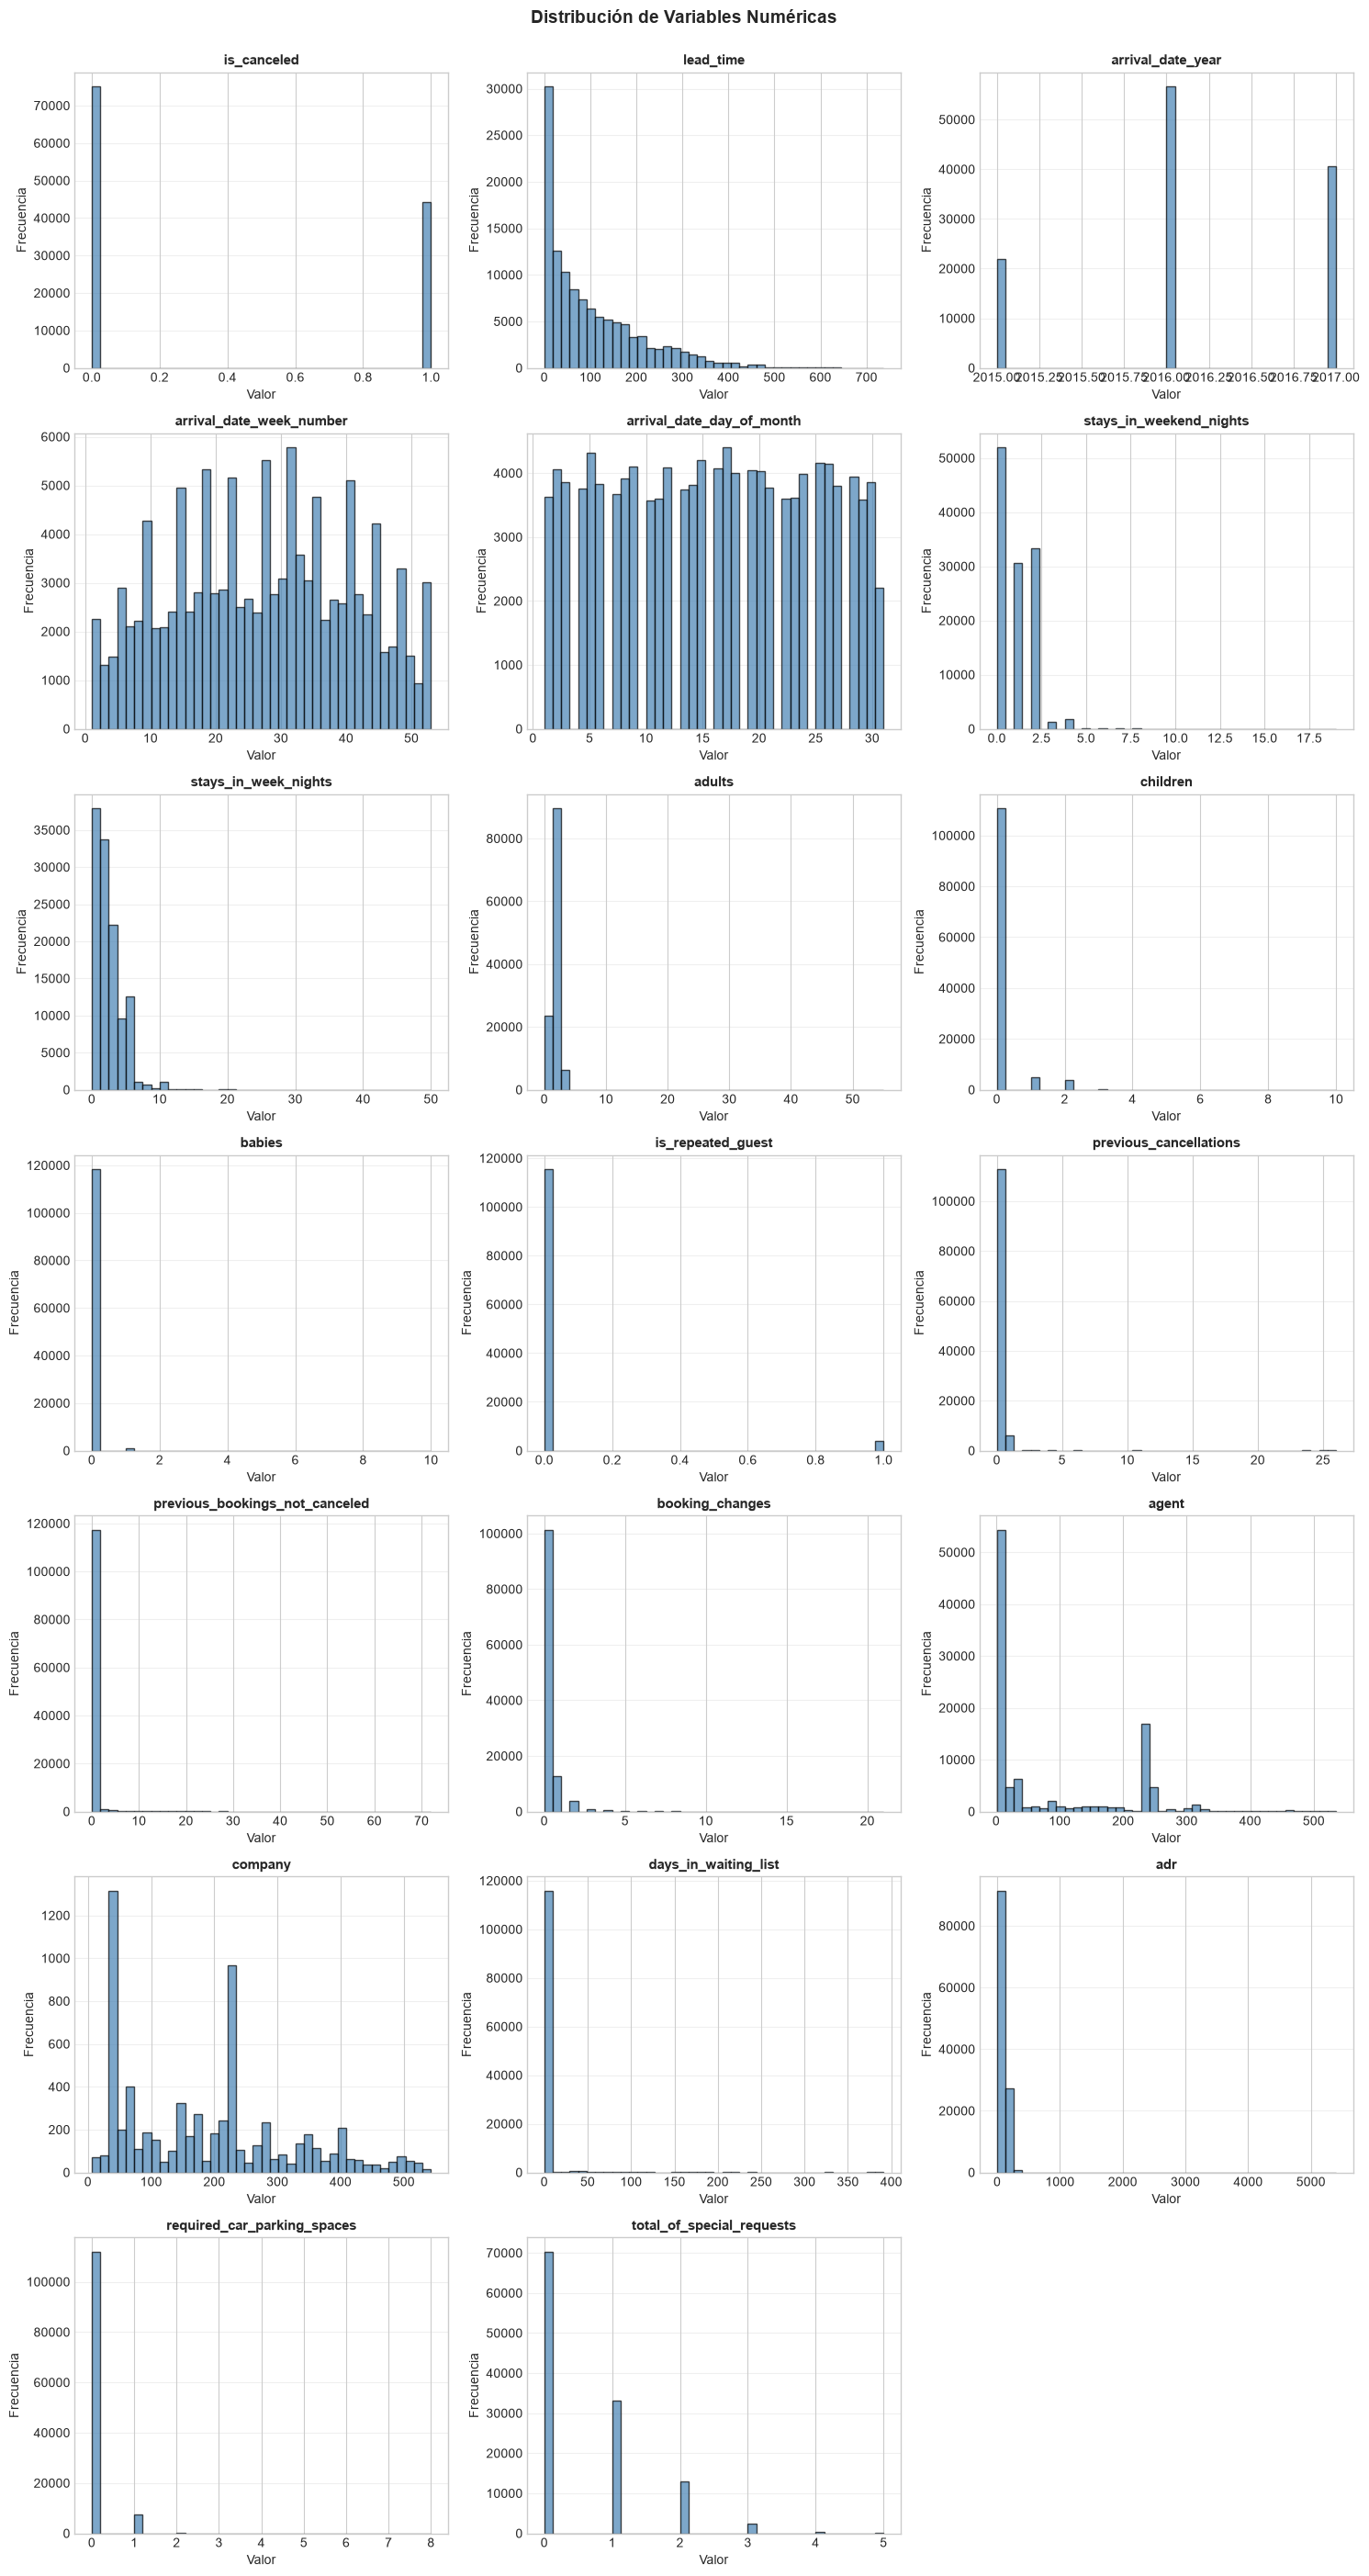


✅ Gráfico de distribuciones guardado y mostrado en notebook


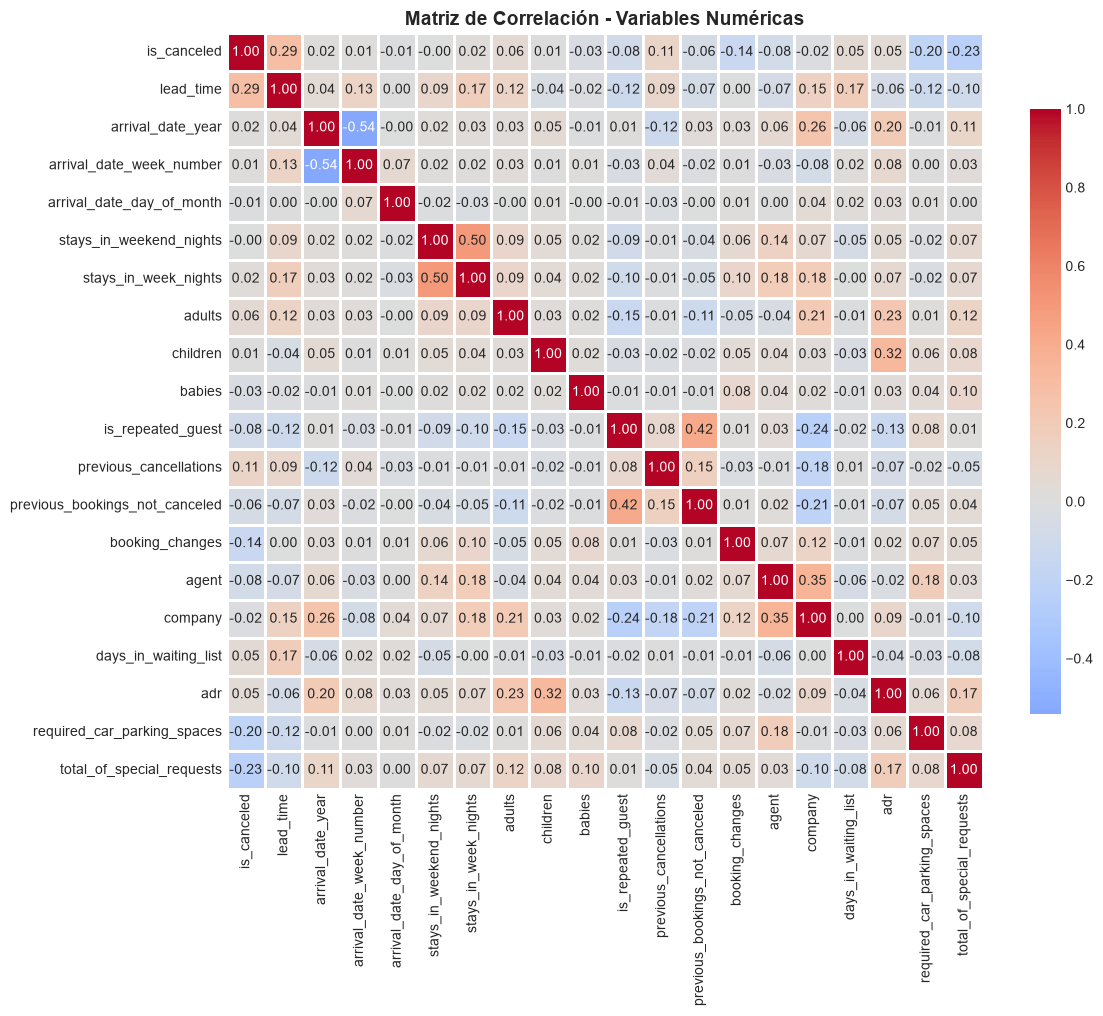

✅ Matriz de correlación guardada y mostrada en notebook


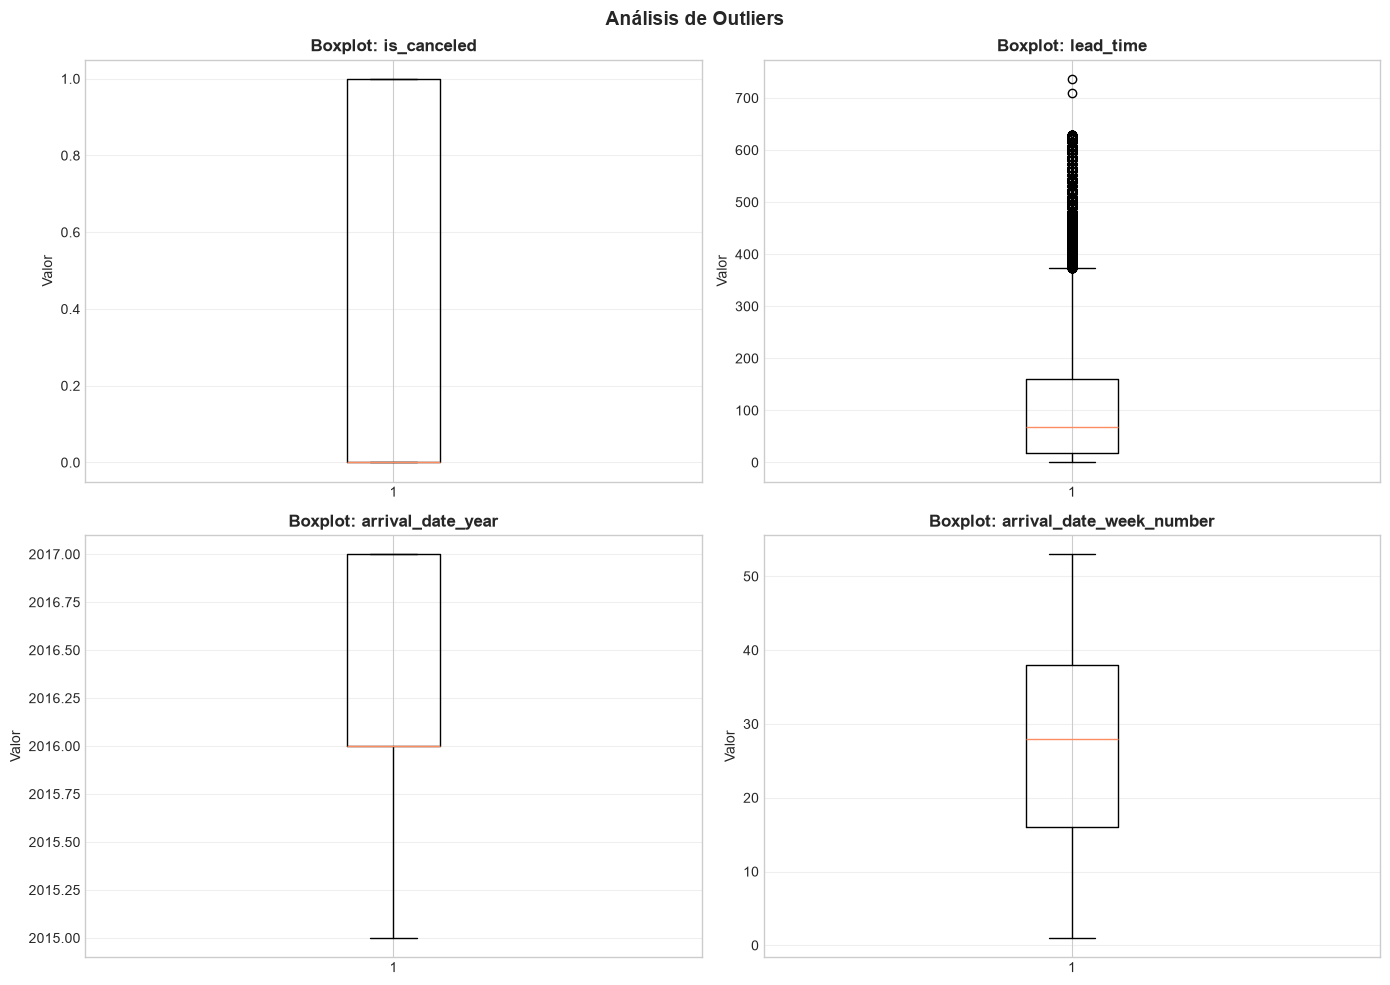

✅ Análisis de outliers guardado y mostrado en notebook


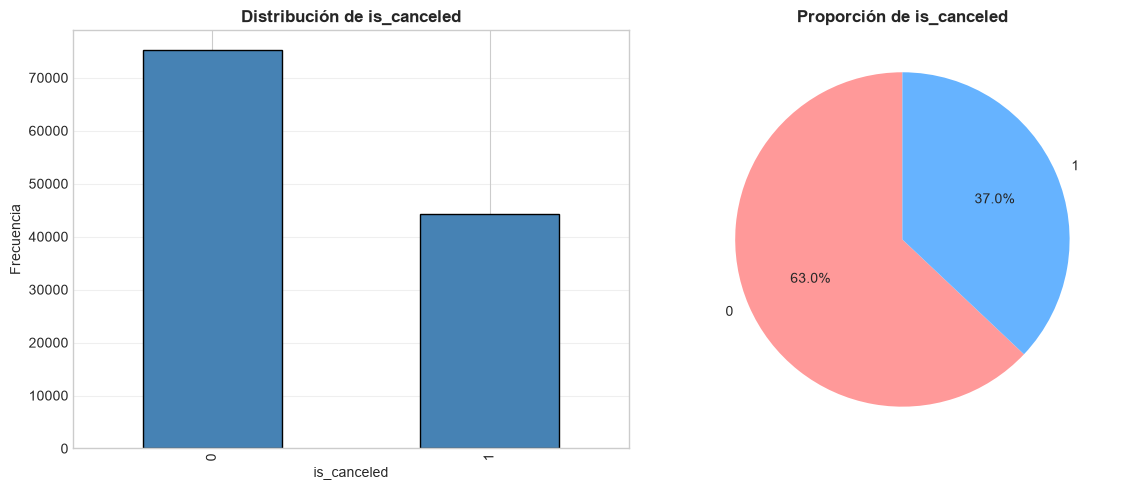

✅ Distribución del target guardada y mostrada en notebook


In [14]:
# SECCIÓN 11: VISUALIZACIONES CLAVE

print("\n" + "="*70)
print("GENERANDO VISUALIZACIONES")
print("="*70)

# Histogramas de variables numéricas
n_numeric = len(numeric_cols)
if n_numeric > 0:
    n_cols = min(3, n_numeric)
    n_rows = (n_numeric + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_numeric > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        data = df[col].dropna()
        axes[idx].hist(data, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frecuencia')
        axes[idx].grid(axis='y', alpha=0.3)
    
    # Ocultar ejes vacíos
    for idx in range(n_numeric, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(OUTPUTS / "01_distribucion_numericas.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Gráfico de distribuciones guardado y mostrado en notebook")

# Matriz de correlación
if len(numeric_cols) > 1:
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUTS / "02_matriz_correlacion.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Matriz de correlación guardada y mostrada en notebook")

# Boxplots para outliers
if len(numeric_cols) >= 2:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(numeric_cols[:4]):
        axes[idx].boxplot(df[col].dropna(), vert=True)
        axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
        axes[idx].set_ylabel('Valor')
        axes[idx].grid(axis='y', alpha=0.3)
    
    for idx in range(len(numeric_cols[:4]), 4):
        axes[idx].set_visible(False)
    
    plt.suptitle('Análisis de Outliers', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUTS / "03_analisis_outliers.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Análisis de outliers guardado y mostrado en notebook")

# Distribución del target
if target_col:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Gráfico de barras
    target_dist.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title(f'Distribución de {target_col}', fontweight='bold')
    axes[0].set_ylabel('Frecuencia')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Gráfico de pie
    axes[1].pie(target_dist.values, labels=target_dist.index, autopct='%1.1f%%',
               startangle=90, colors=['#ff9999', '#66b3ff'])
    axes[1].set_title(f'Proporción de {target_col}', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(OUTPUTS / "04_distribucion_target.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Distribución del target guardada y mostrada en notebook")

In [15]:
# SECCIÓN 12: PREPARACIÓN Y LIMPIEZA DE DATOS

print("\n" + "="*70)
print("PREPARACIÓN Y LIMPIEZA DE DATOS")
print("="*70)

df_clean = df.copy()

# Paso 1: Eliminar duplicados
duplicados_iniciales = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"\n1️⃣  ELIMINACIÓN DE DUPLICADOS")
print(f"   Registros duplicados eliminados: {duplicados_iniciales:,}")
print(f"   Filas antes: {len(df):,}")
print(f"   Filas después: {len(df_clean):,}")
print(f"   Reducción: {duplicados_iniciales / len(df) * 100:.2f}%")

# Paso 2: Manejar valores nulos
print(f"\n2️⃣  MANEJO DE VALORES NULOS")
nulls_handled = 0
for col in df_clean.columns:
    nulls = df_clean[col].isnull().sum()
    if nulls > 0:
        if df_clean[col].dtype in ['float64', 'int64']:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"   ✓ {col}: rellenado con mediana ({nulls} valores)")
        else:
            mode_val = df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else 'Desconocido'
            df_clean[col].fillna(mode_val, inplace=True)
            print(f"   ✓ {col}: rellenado con moda ({nulls} valores)")
        nulls_handled += nulls

# Paso 3: Resumen
print(f"\n3️⃣  RESUMEN DE LIMPIEZA")
print(f"   Valores nulos manejados: {nulls_handled:,}")
print(f"   Duplicados restantes: {df_clean.duplicated().sum()}")
print(f"   Valores nulos restantes: {df_clean.isnull().sum().sum()}")
print(f"   \n   ✅ Dataset limpio y listo para modelado")
print(f"      Forma final: {df_clean.shape[0]:,} × {df_clean.shape[1]}")


PREPARACIÓN Y LIMPIEZA DE DATOS

1️⃣  ELIMINACIÓN DE DUPLICADOS
   Registros duplicados eliminados: 31,994
   Filas antes: 119,390
   Filas después: 87,396
   Reducción: 26.80%

2️⃣  MANEJO DE VALORES NULOS
   ✓ children: rellenado con mediana (4 valores)
   ✓ country: rellenado con moda (452 valores)
   ✓ agent: rellenado con mediana (12193 valores)
   ✓ company: rellenado con mediana (82137 valores)

3️⃣  RESUMEN DE LIMPIEZA
   Valores nulos manejados: 94,786
   Duplicados restantes: 0
   Valores nulos restantes: 94786
   
   ✅ Dataset limpio y listo para modelado
      Forma final: 87,396 × 32


In [24]:
# SECCIÓN 13: EXPORTACIÓN DE RESULTADOS

print("\n" + "="*70)
print("EXPORTACIÓN DE ARTEFACTOS")
print("="*70)

# Guardar dataset limpio
output_file = DATA_PROCESSED / "dataset_cleaned.csv"
df_clean.to_csv(output_file, index=False)
print(f"\n✅ Dataset limpio exportado")
print(f"   Ubicación: {output_file}")
print(f"   Tamaño: {len(df_clean):,} registros × {df_clean.shape[1]} columnas")

# Crear reporte de EDA
report = f"""
# REPORTE DE ANÁLISIS EXPLORATORIO DE DATOS (EDA)
## Generado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

### RESUMEN EJECUTIVO

#### Dataset Original
- **Filas**: {df.shape[0]:,}
- **Columnas**: {df.shape[1]}
- **Duplicados**: {df.duplicated().sum():,} ({df.duplicated().sum() / len(df) * 100:.2f}%)
- **Valores faltantes**: {df.isnull().sum().sum():,} ({df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%)

#### Dataset Procesado
- **Filas**: {len(df_clean):,}
- **Columnas**: {df_clean.shape[1]}
- **Duplicados**: {df_clean.duplicated().sum()}
- **Valores faltantes**: {df_clean.isnull().sum().sum()}
- **Completitud**: 100%

### VARIABLES IDENTIFICADAS

#### Numéricas ({len(numeric_cols)})
{', '.join(numeric_cols)}

#### Categóricas ({len(categorical_cols)})
{', '.join(categorical_cols)}

### TARGET
- **Variable objetivo**: {target_col if target_col else 'No identificada'}
- **Tipo**: {'Clasificación binaria' if target_col and len(df[target_col].unique()) == 2 else 'Multiclase' if target_col else 'N/A'}

### ARCHIVOS GENERADOS
1. `dataset_cleaned.csv` - Dataset procesado y listo para modelado
2. `01_distribucion_numericas.png` - Histogramas de variables numéricas
3. `02_matriz_correlacion.png` - Matriz de correlación
4. `03_analisis_outliers.png` - Boxplots para detección de outliers
5. `04_distribucion_target.png` - Distribución de la variable objetivo

### CONCLUSIONES
- El dataset contiene {len(numeric_cols)} variables numéricas y {len(categorical_cols)} categóricas
- Se eliminaron {df.duplicated().sum():,} registros duplicados ({df.duplicated().sum() / len(df) * 100:.2f}%)
- Se manejaron {nulls_handled:,} valores faltantes mediante imputación
- El dataset está balanceado y listo para etapas posteriores de modelado

**Fecha**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

report_path = PROJECT_ROOT / "REPORTE_EDA.md"
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)

print(f"\n✅ Reporte de EDA generado")
print(f"   Ubicación: {report_path}")

print(f"\n📊 Visualizaciones generadas:")
for file in sorted(OUTPUTS.glob("*.png")):
    print(f"   ✓ {file.name}")

print(f"\n" + "="*70)
print("🎉 ANÁLISIS EXPLORATORIO COMPLETADO")
print("="*70)


EXPORTACIÓN DE ARTEFACTOS

✅ Dataset limpio exportado
   Ubicación: c:\Users\venel\Documents\GitHub\IA0526\PRACTICAML\PRACTICA-MACHINE-LEARNING-\data\processed\dataset_cleaned.csv
   Tamaño: 87,396 registros × 32 columnas

✅ Reporte de EDA generado
   Ubicación: c:\Users\venel\Documents\GitHub\IA0526\PRACTICAML\PRACTICA-MACHINE-LEARNING-\REPORTE_EDA.md

📊 Visualizaciones generadas:
   ✓ 01_distribucion_numericas.png
   ✓ 01_histogramas.png
   ✓ 02_correlacion.png
   ✓ 02_matriz_correlacion.png
   ✓ 03_analisis_outliers.png
   ✓ 04_distribucion_target.png

🎉 ANÁLISIS EXPLORATORIO COMPLETADO
